## Table 4: ViT-Base model's results on CIFAR-10 dataset with Differential Privacy (ε=5) using RTX 4500 Ada GPU

### Section 1: Loading Dataset

In [1]:
import numpy as np
import pandas as pd

In [2]:
vit_base_data=[]
vit_base_data_dp_1=[]
vit_base_data_dp_3=[]
vit_base_data_dp_5=[]
vit_base_data_dp_8=[]
vit_base_data_dp_test_5=[]

for i in range(1,101):
    temp1=[]
    for j in range(10):
        path='/home/rtx3060/Desktop/GPU_Trace/A4500_test/mem_csv_vit_base4/report'+str(j)+'_'+str(i)+'.csv'
        data=pd.read_csv(path)
        temp1.append(data)
    vit_base_data.append(temp1)
    temp1=[]
    for j in range(10):
        path='/home/rtx3060/Desktop/GPU_Trace/A4500_test/mem_csv_vit_base_dp_1.0/report'+str(j)+'_'+str(i)+'.csv'
        data=pd.read_csv(path)
        temp1.append(data)
    vit_base_data_dp_1.append(temp1)
    temp1=[]
    for j in range(10):
        path='/home/rtx3060/Desktop/GPU_Trace/A4500_test/mem_csv_vit_base_dp_3.0/report'+str(j)+'_'+str(i)+'.csv'
        data=pd.read_csv(path)
        temp1.append(data)
    vit_base_data_dp_3.append(temp1)
    temp1=[]
    for j in range(10):
        path='/home/rtx3060/Desktop/GPU_Trace/A4500_test/mem_csv_vit_base_dp_5.0/report'+str(j)+'_'+str(i)+'.csv'
        data=pd.read_csv(path)
        temp1.append(data)
    vit_base_data_dp_5.append(temp1)
    temp1=[]
    for j in range(10):
        path='/home/rtx3060/Desktop/GPU_Trace/A4500_test/mem_csv_vit_base_dp_8.0/report'+str(j)+'_'+str(i)+'.csv'
        data=pd.read_csv(path)
        temp1.append(data)
    vit_base_data_dp_8.append(temp1)


for i in range(1,31):
    temp1=[]
    for j in range(10):
        path='/home/rtx3060/Desktop/GPU_Trace/A4500_test/mem_csv_vit_base_dp_5.0_test/report'+str(j)+'_'+str(i)+'.csv'
        data=pd.read_csv(path)
        temp1.append(data)
    vit_base_data_dp_test_5.append(temp1)

print(vit_base_data[0][1].columns)
print(vit_base_data_dp_test_5[0][1].columns)

Index(['ID', 'Process ID', 'Process Name', 'Host Name', 'Kernel Name',
       'Context', 'Stream', 'Block Size', 'Grid Size', 'Device',
       ...
       'smsp__warps_active.min.peak_sustained',
       'smsp__warps_active.min.per_cycle_active',
       'smsp__warps_active.sum.peak_sustained',
       'smsp__warps_active.sum.per_cycle_active',
       'smsp__warps_eligible.avg.per_cycle_active',
       'smsp__warps_eligible.max.per_cycle_active',
       'smsp__warps_eligible.min.per_cycle_active',
       'smsp__warps_eligible.sum.per_cycle_active', 'thread_inst_executed',
       'thread_inst_executed_true'],
      dtype='object', length=1220)
Index(['ID', 'Process ID', 'Process Name', 'Host Name', 'Kernel Name',
       'Context', 'Stream', 'Block Size', 'Grid Size', 'Device',
       ...
       'smsp__warps_active.min.peak_sustained',
       'smsp__warps_active.min.per_cycle_active',
       'smsp__warps_active.sum.peak_sustained',
       'smsp__warps_active.sum.per_cycle_active',
       'sm

### Section 2: Pre-processing Dataset

In [3]:
for i in range(100):
    for j in range(10):
        vit_base_data[i][j]=vit_base_data[i][j].drop(['ID'], axis=1)
        if 0 in vit_base_data[i][j].index:
            vit_base_data[i][j] = vit_base_data[i][j].drop(index=0)
        vit_base_data_dp_1[i][j]=vit_base_data_dp_1[i][j].drop(['ID'], axis=1)
        if 0 in vit_base_data_dp_1[i][j].index:
            vit_base_data_dp_1[i][j] = vit_base_data_dp_1[i][j].drop(index=0)
        vit_base_data_dp_3[i][j]=vit_base_data_dp_3[i][j].drop(['ID'], axis=1)
        if 0 in vit_base_data_dp_3[i][j].index:
            vit_base_data_dp_3[i][j] = vit_base_data_dp_3[i][j].drop(index=0)
        vit_base_data_dp_5[i][j]=vit_base_data_dp_5[i][j].drop(['ID'], axis=1)
        if 0 in vit_base_data_dp_5[i][j].index:
            vit_base_data_dp_5[i][j] = vit_base_data_dp_5[i][j].drop(index=0)
        vit_base_data_dp_8[i][j]=vit_base_data_dp_8[i][j].drop(['ID'], axis=1)
        if 0 in vit_base_data_dp_8[i][j].index:
            vit_base_data_dp_8[i][j] = vit_base_data_dp_8[i][j].drop(index=0)

for i in range(30):
    for j in range(10):
        vit_base_data_dp_test_5[i][j]=vit_base_data_dp_test_5[i][j].drop(['ID'], axis=1)
        if 0 in vit_base_data_dp_test_5[i][j].index:
            vit_base_data_dp_test_5[i][j] = vit_base_data_dp_test_5[i][j].drop(index=0)



In [4]:
vit_base_data_dp_test_5[0][0]['Kernel Name'].unique

<bound method Series.unique of 1     fmha_cutlassF_f32_aligned_64x64_rf_sm80(Attent...
2     fmha_cutlassF_f32_aligned_64x64_rf_sm80(Attent...
3     fmha_cutlassF_f32_aligned_64x64_rf_sm80(Attent...
4     fmha_cutlassF_f32_aligned_64x64_rf_sm80(Attent...
5     fmha_cutlassF_f32_aligned_64x64_rf_sm80(Attent...
6     fmha_cutlassF_f32_aligned_64x64_rf_sm80(Attent...
7     fmha_cutlassF_f32_aligned_64x64_rf_sm80(Attent...
8     fmha_cutlassF_f32_aligned_64x64_rf_sm80(Attent...
9     fmha_cutlassF_f32_aligned_64x64_rf_sm80(Attent...
10    fmha_cutlassF_f32_aligned_64x64_rf_sm80(Attent...
11    fmha_cutlassF_f32_aligned_64x64_rf_sm80(Attent...
12    fmha_cutlassF_f32_aligned_64x64_rf_sm80(Attent...
Name: Kernel Name, dtype: object>

### Section 3: Metric-based Data filtering and pre-processing

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib
import random

kernel_name=['fmha_cutlassF_f32_aligned_64x64_rf_sm80']
ltx_cols=[col for col in vit_base_data[0][1].columns if 
    col.startswith('smsp__branch_targets_threads_divergent') 
]
for col in ltx_cols:
    for i in range(100):
        for j in range(10):
            if vit_base_data[i][j][col].dtype == 'object':  # likely string
                vit_base_data[i][j][col] = pd.to_numeric(vit_base_data[i][j][col].astype(str).str.replace(',', '').str.strip(), errors='coerce')
            if vit_base_data_dp_1[i][j][col].dtype == 'object':  # likely string
                vit_base_data_dp_1[i][j][col] = pd.to_numeric(vit_base_data_dp_1[i][j][col].astype(str).str.replace(',', '').str.strip(), errors='coerce')
            if vit_base_data_dp_3[i][j][col].dtype == 'object':  # likely string
                vit_base_data_dp_3[i][j][col] = pd.to_numeric(vit_base_data_dp_3[i][j][col].astype(str).str.replace(',', '').str.strip(), errors='coerce')
            if vit_base_data_dp_5[i][j][col].dtype == 'object':  # likely string
                vit_base_data_dp_5[i][j][col] = pd.to_numeric(vit_base_data_dp_5[i][j][col].astype(str).str.replace(',', '').str.strip(), errors='coerce')
            if vit_base_data_dp_8[i][j][col].dtype == 'object':  # likely string
                vit_base_data_dp_8[i][j][col] = pd.to_numeric(vit_base_data_dp_8[i][j][col].astype(str).str.replace(',', '').str.strip(), errors='coerce')
            
    for i in range(30):
        for j in range(10):
            if vit_base_data_dp_test_5[i][j][col].dtype == 'object':  # likely string
                vit_base_data_dp_test_5[i][j][col] = pd.to_numeric(vit_base_data_dp_test_5[i][j][col].astype(str).str.replace(',', '').str.strip(), errors='coerce')

# Optional: update the DataFrame back
print(ltx_cols)
        

['smsp__branch_targets_threads_divergent']


print(len(all_class_data))

In [6]:
vit_base_data_dp_test_5[0][0].shape

(12, 1219)

### Section 4: Generating classifier model's training data and validation data by considering only the filtered Metrics.

In [7]:
col = [col for col in vit_base_data_dp_test_5[0][1].columns if 
    col.startswith('smsp__branch_targets_threads_divergent') 
        or col.startswith('smsp__inst_executed.sum') 
         or col.startswith('smsp__inst_executed_op_shared_atom') 
        or col.startswith('smsp__sass_inst_executed_op_shared_') 
         or col.startswith('smsp__sass_thread_inst_executed_op_fadd_pred_on.min') 
]

for i in range(100):
    for j in range(10):
        for c in col:
            vit_base_data[i][j][c]=pd.to_numeric(vit_base_data[i][j][c].astype(str).str.replace(',', '').str.strip(), errors='coerce').astype('float32')
            vit_base_data_dp_1[i][j][c]=pd.to_numeric(vit_base_data_dp_1[i][j][c].astype(str).str.replace(',', '').str.strip(), errors='coerce').astype('float32')
            vit_base_data_dp_3[i][j][c]=pd.to_numeric(vit_base_data_dp_3[i][j][c].astype(str).str.replace(',', '').str.strip(), errors='coerce').astype('float32')
            vit_base_data_dp_5[i][j][c]=pd.to_numeric(vit_base_data_dp_5[i][j][c].astype(str).str.replace(',', '').str.strip(), errors='coerce').astype('float32')
            vit_base_data_dp_8[i][j][c]=pd.to_numeric(vit_base_data_dp_8[i][j][c].astype(str).str.replace(',', '').str.strip(), errors='coerce').astype('float32')
for i in range(30):
    for j in range(10):
        for c in col:
            vit_base_data_dp_test_5[i][j][c]=pd.to_numeric(vit_base_data_dp_test_5[i][j][c].astype(str).str.replace(',', '').str.strip(), errors='coerce').astype('float32')

# Loop through each DataFrame and keep only the selected columns (if they exist)
vit_base_data_df=[[[] for i in range(10)] for j in range(100)]
vit_base_data_dp_1_df=[[[] for i in range(10)] for j in range(100)]
vit_base_data_dp_3_df=[[[] for i in range(10)] for j in range(100)]
vit_base_data_dp_5_df=[[[] for i in range(10)] for j in range(100)]
vit_base_data_dp_8_df=[[[] for i in range(10)] for j in range(100)]
vit_base_data_dp_test_5_df=[[[] for i in range(10)] for j in range(30)]

for i in range(len(vit_base_data)):
    for j in range(len(vit_base_data[i])):
        df2 = vit_base_data[i][j]
        # Keep only the columns that exist in the current DataFrame
        selected_cols = [c for c in col if c in df2.columns]
        vit_base_data_df[i][j] = vit_base_data[i][j][selected_cols].copy()
        vit_base_data_dp_1_df[i][j] = vit_base_data_dp_1[i][j][selected_cols].copy()
        vit_base_data_dp_3_df[i][j] = vit_base_data_dp_3[i][j][selected_cols].copy()
        vit_base_data_dp_5_df[i][j] = vit_base_data_dp_5[i][j][selected_cols].copy()
        vit_base_data_dp_8_df[i][j] = vit_base_data_dp_8[i][j][selected_cols].copy()
        
for i in range(len(vit_base_data_dp_test_5)):
    for j in range(len(vit_base_data_dp_test_5[i])):
        df2 = vit_base_data_dp_test_5[i][j]
        # Keep only the columns that exist in the current DataFrame
        selected_cols = [c for c in col if c in df2.columns]
        vit_base_data_dp_test_5_df[i][j] = vit_base_data_dp_test_5[i][j][selected_cols].copy()

In [8]:
print(col)

['smsp__branch_targets_threads_divergent', 'smsp__inst_executed.sum', 'smsp__inst_executed_op_shared_atom.sum', 'smsp__inst_executed_op_shared_atom.sum.pct_of_peak_sustained_elapsed', 'smsp__sass_inst_executed_op_shared_ld.sum', 'smsp__sass_inst_executed_op_shared_st.sum', 'smsp__sass_thread_inst_executed_op_fadd_pred_on.min.per_cycle_elapsed']


In [9]:
vit_base_data_dp_test_5_df[0][0].shape

(12, 7)

### Dataset re-arrangement and providing label for training and test samples for both shadow and target model. Also, selecting appropiate range of FMHA kernel instances for achieving maximum attack success rate.

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train=[]
y_train=[]
X_test=[]
y_test=[]
for i in range(100):
    for j in range(10):
        a=vit_base_data_df[i][j]
        b=vit_base_data_dp_1_df[i][j]
        c=vit_base_data_dp_3_df[i][j]
        d=vit_base_data_dp_5_df[i][j]
        e=vit_base_data_dp_8_df[i][j]

        X_train.append(a)
        X_train.append(b)
        X_train.append(c)
        X_train.append(d)
        X_train.append(e)
        if i<50: 
            y_train.append(1)
            y_train.append(1)
            y_train.append(1)
            y_train.append(1)
            y_train.append(1)
        else: 
            y_train.append(0)
            y_train.append(0)
            y_train.append(0)
            y_train.append(0)
            y_train.append(0)

for i in range(30):
    for j in range(10):
        d=vit_base_data_dp_test_5_df[i][j]
        X_test.append(d)
        if i<15: 
            y_test.append(1)
        else: 
            y_test.append(0)

X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

X_train = X_train[:, 0:5, :]
X_test = X_test[:, 0:5, :]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(5000, 5, 7) (5000,)
(300, 5, 7) (300,)


In [11]:
import numpy as np
print(np.unique(y_train, return_counts=True))
print(np.unique(y_test, return_counts=True))

(array([0, 1]), array([2500, 2500]))
(array([0, 1]), array([150, 150]))


In [12]:
from tensorflow.keras.utils import to_categorical

2026-08-24 19:48:20.449090: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-24 19:48:20.458898: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1787581100.470162 3891107 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1787581100.473643 3891107 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1787581100.482821 3891107 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

### Attack Classifier training

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, BatchNormalization
import numpy as np
from sklearn.model_selection import train_test_split

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  
def reset_random_seeds():
   os.environ['PYTHONHASHSEED']=str(42)
   tf.random.set_seed(42)
   np.random.seed(42)
   random.seed(42)
reset_random_seeds()
import tensorflow as tf

# Your input data shape: (samples, sequence_length, feature_dim)
num_samples = X_train.shape[0]
sequence_length = X_train.shape[1]
feature_dim = X_train.shape[2]

# Define the model
# Stacked BiLSTM Layers
model = Sequential()
model.add(Bidirectional(LSTM(64, return_sequences=True), input_shape=(sequence_length, feature_dim)))
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(32, return_sequences=False)))
model.add(Dropout(0.2))

# Fully connected hidden layer
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

mean = X_train.mean(axis=(0, 1), keepdims=True)
std = X_train.std(axis=(0, 1), keepdims=True)
X_train = (X_train - mean) / (std + 1e-8)

# Summary
model.summary()
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
# Train
history = model.fit(
    X_train_split, y_train_split,
    epochs=90,
    batch_size=40,
    validation_data=(X_val_split, y_val_split)
)

2026-08-24 19:48:21.770167: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-08-24 19:48:21.770188: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:167] env: CUDA_VISIBLE_DEVICES="-1"
2026-08-24 19:48:21.770192: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:170] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
2026-08-24 19:48:21.770193: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:178] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2026-08-24 19:48:21.770196: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:183] retrieving CUDA diagnostic information for host: rtx3060-MS-7D90
2026-08-24 19:48:21.770198: I external/local_xla/xla/stream_executor/cu

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 5, 128)         │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,305 (321.50 KB)

 Trainable params: 82,305 (321.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/90
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5398 - loss: 0.6868 - val_accuracy: 0.5760 - val_loss: 0.6712
Epoch 2/90
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5866 - loss: 0.6632 - val_accuracy: 0.6020 - val_loss: 0.6422
Epoch 3/90
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6015 - loss: 0.6358 - val_accuracy: 0.5930 - val_loss: 0.6203
Epoch 4/90
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6212 - loss: 0.6194 - val_accuracy: 0.6310 - val_loss: 0.6021
Epoch 5/90
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6481 - loss: 0.5910 - val_accuracy: 0.6480 - val_loss: 0.5737
Epoch 6/90
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6694 - loss: 0.5698 - val_accuracy: 0.6910 - val_loss: 0.5591
Epoch 7/90
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7134 - loss: 0.5509 - val_accuracy: 0.7140 - val_loss: 0.5269
Epoch 8/90
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7202 - loss: 0.5229 - val_accuracy: 0.

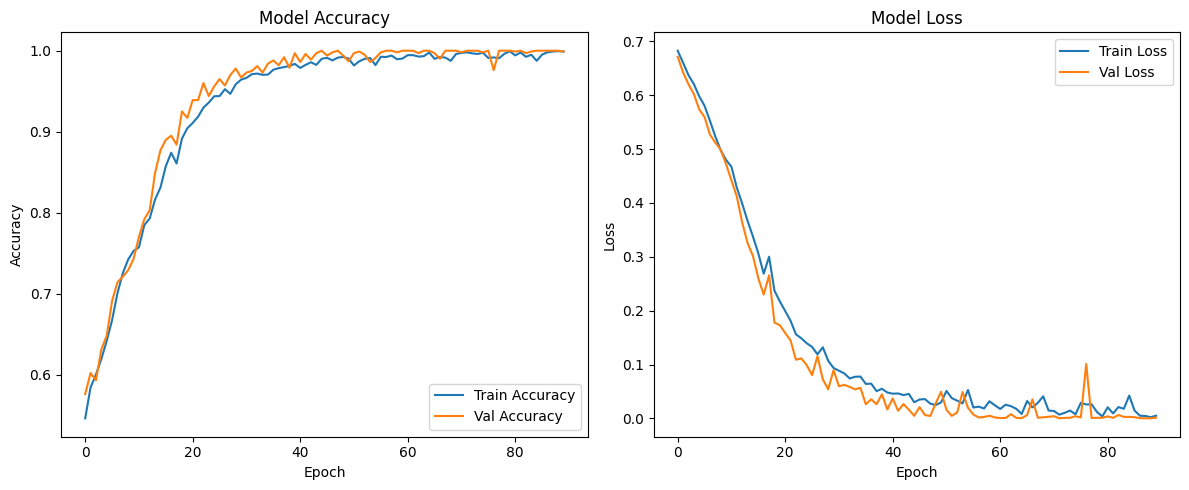

In [14]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


### Membership Inference Attack on Target Model Data

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Test Accuracy: 0.9833
Confusion Matrix:
 [[150   0]
 [  5 145]]


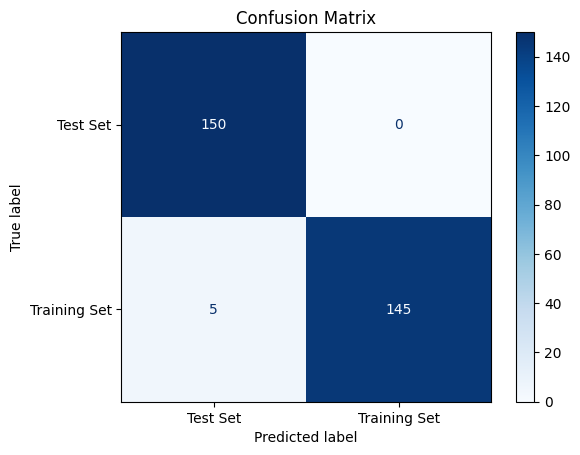

In [15]:
# Predict
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

mean = X_test.mean(axis=(0, 1), keepdims=True)
std = X_test.std(axis=(0, 1), keepdims=True)
X_test = (X_test - mean) / (std + 1e-8)
# Predict probabilities
predictions = model.predict(X_test)

# # Convert probabilities to binary labels
predicted_labels = (predictions > 0.5).astype(int)

# Accuracy
acc = accuracy_score(y_test, predicted_labels)
print(f"Test Accuracy: {acc:.4f}")


# Confusion matrix
cm = confusion_matrix(y_test, predicted_labels)
print("Confusion Matrix:\n", cm)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Test Set", "Training Set"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()



F1 Score: 0.9831
AUC Score: 0.9992


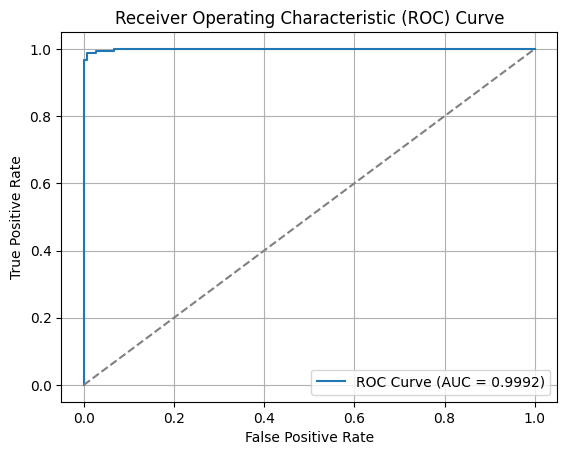

In [16]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    f1_score
)
import matplotlib.pyplot as plt
import numpy as np

# Binary predictions using threshold 0.5
predicted_labels = (predictions >= 0.5).astype(int)

# F1 Score
f1 = f1_score(y_test, predicted_labels)
print(f"F1 Score: {f1:.4f}")

# AUC Score
auc_score = roc_auc_score(y_test, predictions)
print(f"AUC Score: {auc_score:.4f}")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, predictions)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Random chance line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()